# Social Buzz — which categories get reactions?

Forage / Accenture virtual experience. Popularity = **sum of reaction scores**, not the number of reactions.

This notebook:
1. Loads the joined table
2. Cleans category labels
3. Ranks categories
4. Adds a few extra cuts (sentiment, format, month)
5. Saves charts to `reports/figures/`
6. Repeats the ranking in SQL (SQLite) so the pandas and SQL answers match


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..") if Path("..").joinpath("data").exists() else Path(".")
# notebook lives in notebooks/; data is one level up
for cand in [Path(".."), Path("."), Path("/workspace/artifacts/social-buzz-analytics")]:
    if (cand / "data" / "cleaned_reactions.csv").exists():
        ROOT = cand
        break

DATA = ROOT / "data" / "cleaned_reactions.csv"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
print("data:", DATA)


data: ../data/cleaned_reactions.csv


## Load and clean

In [2]:
df = pd.read_csv(DATA)
print(df.shape)
print(df.columns.tolist())
print(df.isna().sum().to_dict())

df["category"] = (
    df["Content_Category"].astype(str)
    .str.replace('"', "", regex=False)
    .str.strip()
    .str.lower()
)
df["dt"] = pd.to_datetime(df["Datetime"], dayfirst=True)
print("rows", len(df), "posts", df["Content_ID"].nunique(), "users", df["User_ID"].nunique())
print("categories", df["category"].nunique(), sorted(df["category"].unique()))
print("window", df["dt"].min(), "→", df["dt"].max())


(22534, 8)
['Content_ID', 'User_ID', 'Type', 'Datetime', 'Content_Type', 'Content_Category', 'Sentiment', 'Reaction_Score']
{'Content_ID': 0, 'User_ID': 0, 'Type': 0, 'Datetime': 0, 'Content_Type': 0, 'Content_Category': 0, 'Sentiment': 0, 'Reaction_Score': 0}
rows 22534 posts 962 users 500
categories 16 ['animals', 'cooking', 'culture', 'dogs', 'education', 'fitness', 'food', 'healthy eating', 'public speaking', 'science', 'soccer', 'studying', 'technology', 'tennis', 'travel', 'veganism']
window 2020-06-18 08:07:00 → 2021-06-18 08:30:00


Quoted labels like `"animals"` are the same topic as `Animals`. After that merge there are **16** categories, not 17.


## Rank by popularity score

In [3]:
score = (
    df.groupby("category")["Reaction_Score"]
    .agg(score="sum", reactions="count", mean_score="mean")
    .sort_values("score", ascending=False)
)
score["share_pct"] = 100 * score["score"] / score["score"].sum()
score.index = score.index.str.title()
display(score.round(2))
print("top 5 share %", round(score.head(5)["share_pct"].sum(), 2))
print("total score", int(score["score"].sum()))


,score,reactions,mean_score,share_pct
category,,,,
Animals,68624,1738,39.48,7.68
Science,65405,1646,39.74,7.32
Healthy Eating,63138,1572,40.16,7.07
Technology,63035,1557,40.48,7.05
Food,61598,1556,39.59,6.89
Culture,60663,1538,39.44,6.79
Travel,59358,1510,39.31,6.64
Cooking,59174,1525,38.80,6.62
Soccer,53216,1339,39.74,5.96


top 5 share % 36.02
total score 893482


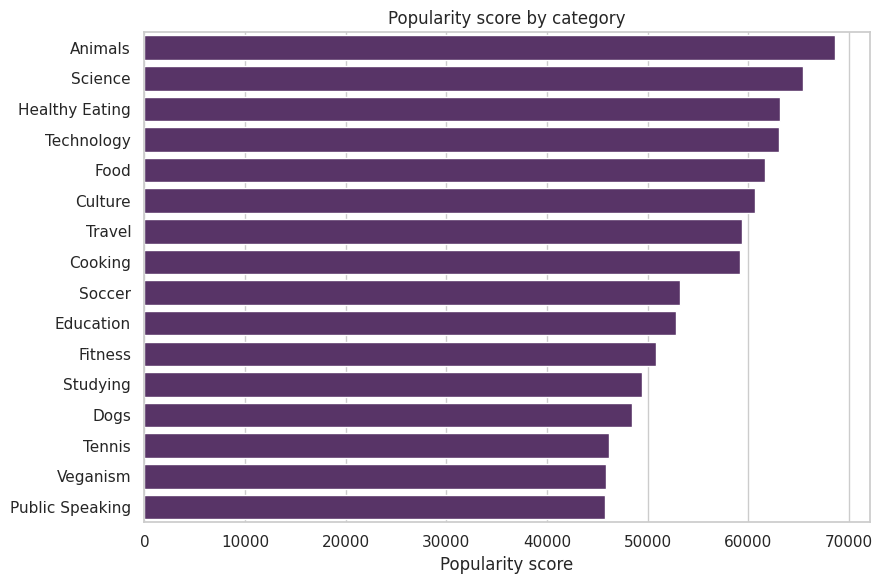

In [4]:
PURPLE = "#5B2C6F"
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(y=score.index, x=score["score"], ax=ax, color=PURPLE)
ax.set_xlabel("Popularity score")
ax.set_ylabel("")
ax.set_title("Popularity score by category")
fig.tight_layout()
fig.savefig(FIG / "score_by_category.png", dpi=150)
plt.show()


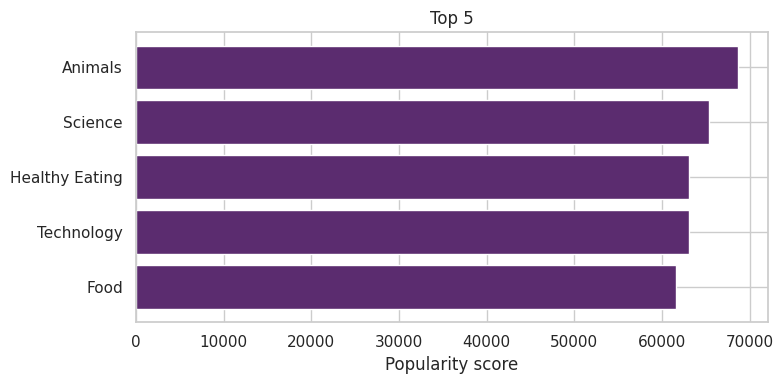

In [5]:
top = score.head(5).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top.index, top["score"], color=PURPLE)
ax.set_title("Top 5")
ax.set_xlabel("Popularity score")
fig.tight_layout()
fig.savefig(FIG / "top5_score.png", dpi=150)
plt.show()


Animals leads on **both** count (1,738) and score (68,624). Mean score is ~40 for almost every category, so the ranking is mostly volume.

Public speaking has the highest mean (41.0) and the lowest volume.


## Time

dt
2020    12195
2021    10339
Name: count, dtype: int64
dt
May          1954
January      1949
August       1945
December     1941
October      1889
July         1884
November     1866
September    1862
March        1857
June         1836
April        1801
February     1750
Name: count, dtype: int64
dt
2021-05    1954
2021-01    1949
2020-08    1945
Freq: M, dtype: int64


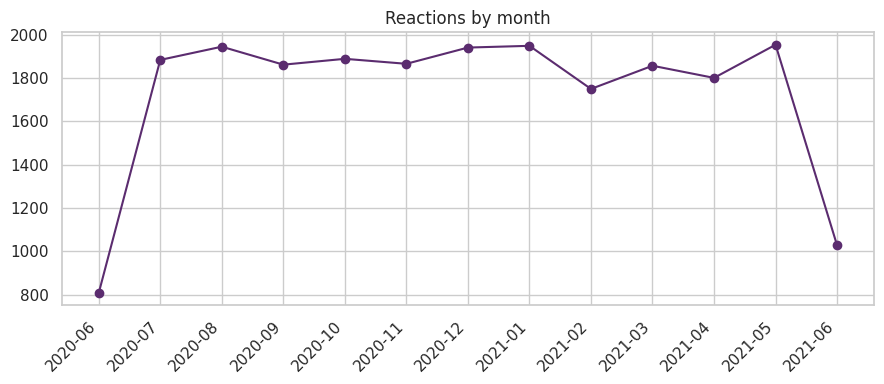

In [6]:
print(df["dt"].dt.year.value_counts().sort_index())
print(df["dt"].dt.month_name().value_counts())
monthly = df.groupby(df["dt"].dt.to_period("M")).size()
print(monthly.sort_values(ascending=False).head(3))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index.astype(str), monthly.values, marker="o", color=PURPLE)
plt.xticks(rotation=45, ha="right")
ax.set_title("Reactions by month")
fig.tight_layout()
fig.savefig(FIG / "reactions_by_month.png", dpi=150)
plt.show()


## Sentiment and format

In [7]:
print((df["Sentiment"].value_counts(normalize=True)*100).round(1))
print(df.groupby("Content_Type")["Reaction_Score"].sum().sort_values(ascending=False))

top_names = score.head(5).index.str.lower()
sub = df[df["category"].isin(top_names)]
sent = pd.crosstab(sub["category"], sub["Sentiment"], normalize="index") * 100
display(sent.round(1))


Sentiment
positive    56.2
negative    31.2
neutral     12.5
Name: proportion, dtype: float64
Content_Type
photo    241090
video    225559
GIF      218922
audio    207911
Name: Reaction_Score, dtype: int64


Sentiment,negative,neutral,positive
category,,,
animals,32.6,12.1,55.4
food,31.7,12.3,56.0
healthy eating,30.3,12.7,57.0
science,29.8,13.4,56.7
technology,29.9,12.6,57.5


## Takeaways

1. Animals, Science, Healthy eating, Technology, Food.
2. Use **score**, not count — 1,738 is reactions, 68,624 is popularity.
3. Do not pitch “2021 was the peak year”; 2020 has more rows in this window.
4. Healthy eating over Food is a useful split for partnerships.


## Same ranking in SQL

The CSV is loaded into an in-memory SQLite database. The query is the same
idea as the pandas `groupby`: clean the category, `SUM(score)`, sort.
The `.sql` file under `sql/top_categories.sql` is this query without Python.


In [ ]:
import sqlite3

work = df.copy()
work["category"] = (
    work["Content_Category"].astype(str).str.replace('"', "", regex=False).str.strip().str.lower()
)

con = sqlite3.connect(":memory:")
work.to_sql("reactions", con, index=False, if_exists="replace")

sql = """
WITH cleaned AS (
    SELECT
        lower(trim(replace(Content_Category, '"', ''))) AS category,
        Reaction_Score AS score
    FROM reactions
)
SELECT
    category,
    SUM(score) AS popularity_score,
    COUNT(*) AS reactions,
    ROUND(AVG(score), 2) AS mean_score
FROM cleaned
GROUP BY category
ORDER BY popularity_score DESC
LIMIT 5
"""
sql_top5 = pd.read_sql(sql, con)
display(sql_top5)

pandas_top5 = (
    work.groupby("category")["Reaction_Score"].sum().sort_values(ascending=False).head(5)
)
print("pandas and SQL scores match:",
      list(sql_top5["popularity_score"]) == list(pandas_top5.values))
con.close()
